In [1]:
#!pip install datasets

In [2]:
import pandas as pd

In [3]:
from datasets import Dataset

df = pd.read_csv("dataset.csv")

dataset = Dataset.from_pandas(df)


In [4]:
dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.2)

## Tokenize texts with Hugging Face

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/333447 [00:00<?, ? examples/s]

Map:   0%|          | 0/83362 [00:00<?, ? examples/s]

## Create Model for Text Classification

In [6]:
from transformers import AutoModelForSequenceClassification

labels = list(set(df['label']))
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

def encode_labels(example):
    example['label'] = label2id[example['label']]
    return example

tokenized_datasets = tokenized_datasets.map(encode_labels)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilroberta-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

Map:   0%|          | 0/333447 [00:00<?, ? examples/s]

Map:   0%|          | 0/83362 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
#!pip install accelerate

In [12]:
from transformers import TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Evaluation functions
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./emotion_model",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    logging_dir="./logs"
)

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


C:\Users\Diego Maldonado\AppData\Local\Temp\ipykernel_2708\1134722179.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## Entrenar modelo

In [13]:
trainer.train()

Step,Training Loss
500,0.360800
1000,0.196600
1500,0.161300
2000,0.147100
2500,0.136300
3000,0.128700
3500,0.121500
4000,0.120300
4500,0.122500
5000,0.112200


TrainOutput(global_step=31263, training_loss=0.10373875202778925, metrics={'train_runtime': 12519.4929, 'train_samples_per_second': 79.903, 'train_steps_per_second': 2.497, 'total_flos': 1.3473976227653988e+16, 'train_loss': 0.10373875202778925, 'epoch': 3.0})

## Save trained model

In [14]:
trainer.save_model("./emotion_model")
tokenizer.save_pretrained("./emotion_model")

('./emotion_model\\tokenizer_config.json',
 './emotion_model\\special_tokens_map.json',
 './emotion_model\\vocab.json',
 './emotion_model\\merges.txt',
 './emotion_model\\added_tokens.json',
 './emotion_model\\tokenizer.json')

## Usar el modelo para predicción

In [2]:
from transformers import pipeline
classifier = pipeline("text-classification", model="./emotion_model", tokenizer="./emotion_model")

Device set to use cuda:0


In [1]:
classifier("i like the class of machine learning")

NameError: name 'classifier' is not defined

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     24240
           1       0.92      1.00      0.96     28110
           2       1.00      0.70      0.83      6974
           3       0.94      0.95      0.95     11552
           4       0.85      0.99      0.91      9475
           5       0.99      0.65      0.78      3011

    accuracy                           0.94     83362
   macro avg       0.95      0.87      0.90     83362
weighted avg       0.95      0.94      0.94     83362



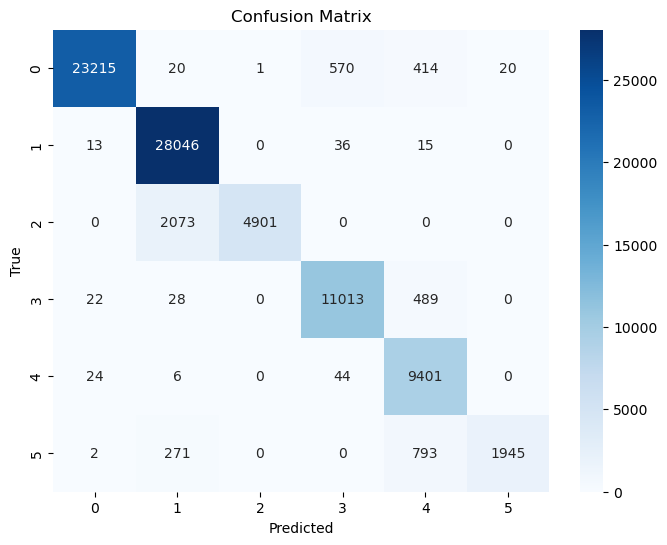

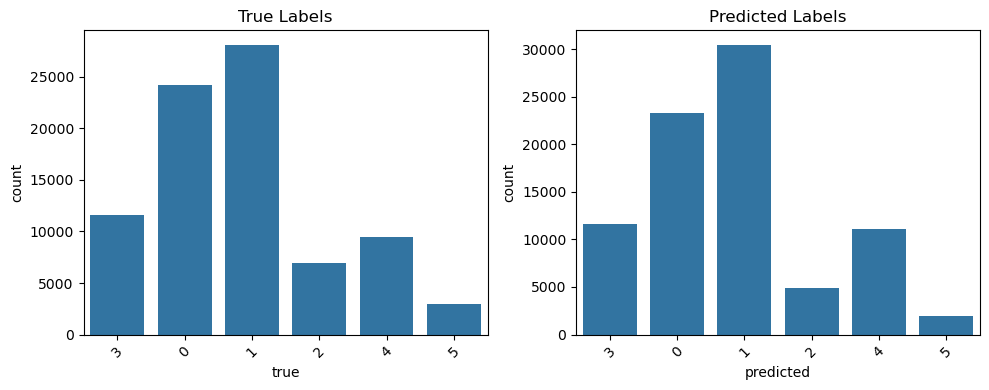

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Get predictions of the trained model
preds_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(preds_output.predictions, axis=1)
labels = preds_output.label_ids

# Ensure id2label values are strings
id2label_str = {i: str(label) for i, label in id2label.items()}

# Classification report
target_names = [id2label_str[i] for i in sorted(id2label_str)]
print(classification_report(labels, preds, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Real count vs. obtained
results_df = pd.DataFrame({
    "true": [id2label_str[i] for i in labels],
    "predicted": [id2label_str[i] for i in preds]
})

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="true", data=results_df)
plt.title("True Labels")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x="predicted", data=results_df)
plt.title("Predicted Labels")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
